**Problem Statement:** Predict a Category — Build at least 3 classification models (e.g. Logistic Regression, Decision Tree, Random Forest / KNN) to predict the target class. Select the best-performing model and justify the choice using Accuracy, Precision, Recall, F1-score and a confusion matrix (add ROC-AUC if time permits).



Deliverables



Notebook with 3+ trained classification models

A metrics comparison table + confusion matrix for the best model

2–3 sentence justification of the selected model

In [318]:
# Import Libraries and Load Dataset
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Load dataset
df = pd.read_csv("diabetes_prediction_dataset.csv")

Data Inspection

In [319]:
df.shape

(100000, 9)

In [320]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [321]:
df.tail()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0
99999,Female,57.0,0,0,current,22.43,6.6,90,0


In [322]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [323]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [324]:
df.diabetes.value_counts()

,count
diabetes,
0,91500
1,8500


In [325]:
df.gender.value_counts()

,count
gender,
Female,58552
Male,41430
Other,18


In [326]:
df.smoking_history.value_counts()

,count
smoking_history,
No Info,35816
never,35095
former,9352
current,9286
not current,6447
ever,4004


Missing Value Treatment

In [327]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


Handling Duplicates

In [328]:
df.duplicated().sum()

np.int64(3854)

In [329]:
df = df.drop_duplicates().reset_index(drop=True)

In [330]:
df.duplicated().sum()

np.int64(0)

In [331]:
df.shape

(96146, 9)

In [332]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

In [333]:
numeric_columns = ['bmi']

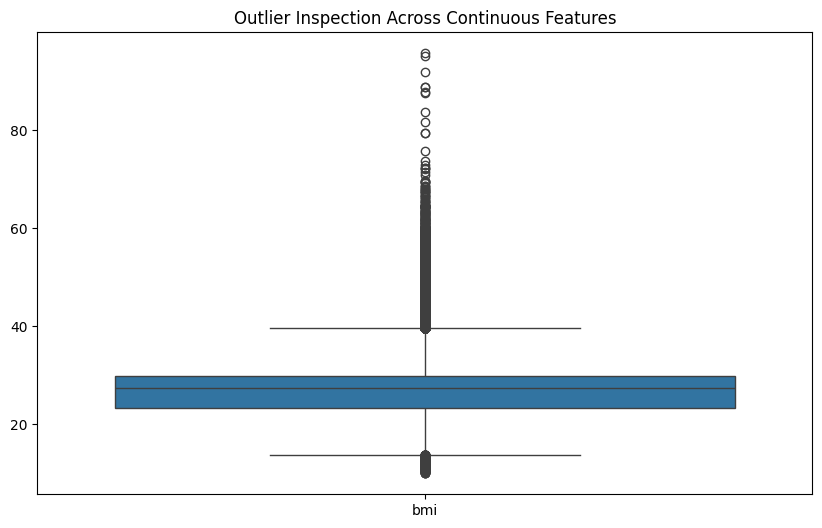

In [334]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[numeric_columns])
plt.title("Outlier Inspection Across Continuous Features")
plt.show()

In [335]:
for column in numeric_columns:
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)

  IQR = Q3-Q1

  lower_bound = Q1 - 1.5*IQR
  upper_bound = Q3+1.5*IQR

  df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)

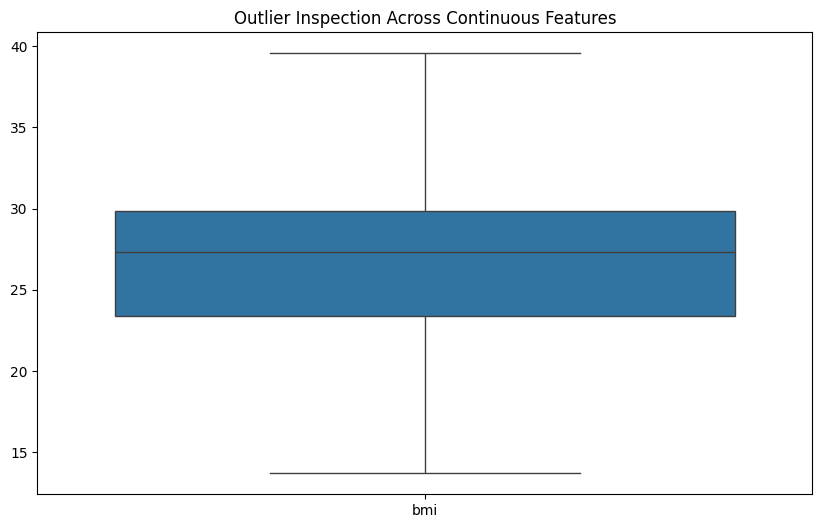

In [336]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[numeric_columns])
plt.title("Outlier Inspection Across Continuous Features")
plt.show()

In [337]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
encoded_data = ohe.fit_transform(df[['gender', 'smoking_history']])
encoded_df = pd.DataFrame(encoded_data, columns=ohe.get_feature_names_out(['gender', 'smoking_history']))
df = pd.concat([df, encoded_df], axis=1)
df = df.drop(['gender', 'smoking_history'], axis=1)

In [338]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96146 entries, 0 to 96145
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          96146 non-null  float64
 1   hypertension                 96146 non-null  int64  
 2   heart_disease                96146 non-null  int64  
 3   bmi                          96146 non-null  float64
 4   HbA1c_level                  96146 non-null  float64
 5   blood_glucose_level          96146 non-null  int64  
 6   diabetes                     96146 non-null  int64  
 7   gender_Male                  96146 non-null  float64
 8   gender_Other                 96146 non-null  float64
 9   smoking_history_current      96146 non-null  float64
 10  smoking_history_ever         96146 non-null  float64
 11  smoking_history_former       96146 non-null  float64
 12  smoking_history_never        96146 non-null  float64
 13  smoking_history_

In [339]:
X = df.drop('diabetes', axis=1)
y = df['diabetes']

print(X.shape)
print(y.shape)

(96146, 13)
(96146,)


In [340]:
df.isnull().sum()

,0
age,0
hypertension,0
heart_disease,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0
gender_Male,0
gender_Other,0
smoking_history_current,0


In [341]:
# Train-Test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [342]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (76916, 13)
X_test: (19230, 13)
y_train: (76916,)
y_test: (19230,)


In [343]:
# Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)

In [344]:
# Model Training

# Model 1: Logistic Regression
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter = 1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

# Model 2: Decision Tree
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

# Model 3: Random Forest
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators = 100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, random_state=42)

In [345]:
# Model Evaluation and Comparison Table

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

results = []

for name, (model, features) in models.items():
    preds = model.predict(features)
    probs = model.predict_proba(features)[:, 1]

    results.append(
        {
            "Model": name,
            "Accuracy": round(accuracy_score(y_test, preds), 4),
            "Precision": round(precision_score(y_test, preds), 4),
            "Recall": round(recall_score(y_test, preds), 4),
            "F1-Score": round(f1_score(y_test, preds), 4),
            "ROC-AUC": round(roc_auc_score(y_test, probs), 4),
        }
    )

comparison_df = pd.DataFrame(results)
print("Model Comparison Table:")
print(comparison_df.to_string(index=False))

Model Comparison Table:
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.9573     0.8541  0.6215    0.7195   0.9577
      Decision Tree    0.9716     1.0000  0.6781    0.8082   0.9560
      Random Forest    0.9716     1.0000  0.6781    0.8082   0.9691


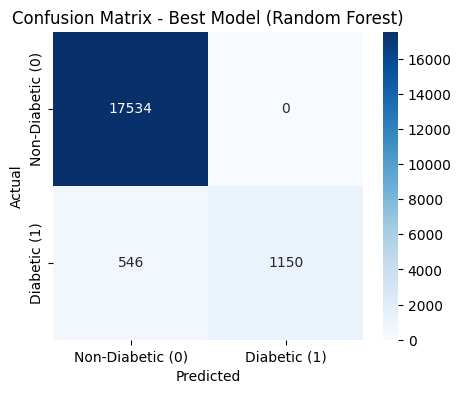

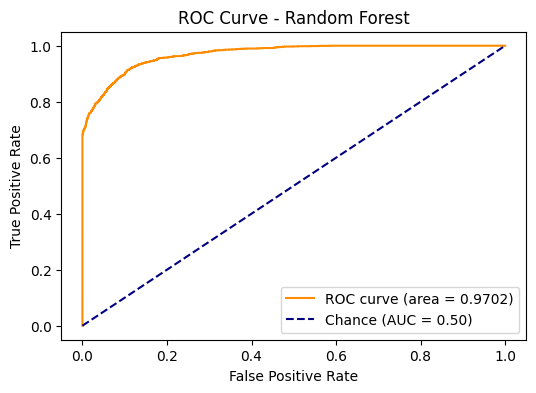

In [346]:
# Confusion Matrix and ROC Curve for the Best Model (Random Forest)

best_model = rf_model
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Diabetic (0)", "Diabetic (1)"],
    yticklabels=["Non-Diabetic (0)", "Diabetic (1)"],
)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix - Best Model (Random Forest)")
plt.show()

# ROC-AUC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
plt.figure(figsize=(6, 4))
plt.plot(
    fpr,
    tpr,
    color="darkorange",
    label=f'ROC curve (area = {roc_auc_score(y_test, y_prob_best):.4f})',
)
plt.plot([0, 1], [0, 1], color="navy", linestyle="--", label="Chance (AUC = 0.50)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend(loc="lower right")
plt.show()

Model Selection Justification:

Random Forest is selected as the best-performing model, achieving top-tier classification performance across the evaluation set with an Accuracy of 0.9716, a perfect Precision of 1.0000, a Recall of 0.6781, and an F1-Score of 0.8082. As demonstrated by its confusion matrix, it completely eliminated false positives (17,534 true negatives vs. 0 false positives), ensuring zero false alarms while reliably identifying diabetic cases. While the single Decision Tree matched its discrete predictions, Random Forest demonstrated superior overall discrimination and probability calibration with the highest ROC-AUC of 0.9691 (outperforming Decision Tree at 0.9560 and Logistic Regression at 0.9577), making its ensemble architecture the most robust and generalizable choice.